In [122]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [123]:
#Importing Libraries
import pandas as pd # Data Analysis and Manipulation
import numpy as np  # complex numerical Computation in the form of arrays and matrix
import seaborn as sns # Visualization tool

#NLP TOOLS for Text Preprocessing
import nltk
nltk.download('punkt_tab')

#Ignore warnings in output
import warnings
warnings.filterwarnings('ignore')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [124]:
#Loading the Data
df = pd.read_csv('/content/drive/MyDrive/wrenchwise/emails.csv',encoding='latin1')
print("Data loaded successfully.")


#EDA --> Exploratory Data Analysis
#Summarize the Data
df.info()


Data loaded successfully.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5728 entries, 0 to 5727
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    5728 non-null   object
 1   spam    5728 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 89.6+ KB


In [125]:
df.head()

,text,spam
0,"Subject: naturally irresistible your corporate identity lt is really hard to recollect a company : the market is full of suqgestions and the information isoverwhelminq ; but a good catchy logo , stylish statlonery and outstanding website will make the task much easier . we do not promise that havinq ordered a iogo your company will automaticaily become a world ieader : it isguite ciear that without good products , effective business organization and practicable aim it will be hotat nowadays market ; but we do promise that your marketing efforts will become much more effective . here is the list of clear benefits : creativeness : hand - made , original logos , specially done to reflect your distinctive company image . convenience : logo and stationery are provided in all formats ; easy - to - use content management system letsyou change your website content and even its structure . promptness : you will see logo drafts within three business days . affordability : your marketing break - through shouldn ' t make gaps in your budget . 100 % satisfaction guaranteed : we provide unlimited amount of changes with no extra fees for you to be surethat you will love the result of this collaboration . have a look at our portfolio _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ not interested . . . _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _",1
1,Subject: the stock trading gunslinger fanny is merrill but muzo not colza attainder and penultimate like esmark perspicuous ramble is segovia not group try slung kansas tanzania yes chameleon or continuant clothesman no libretto is chesapeake but tight not waterway herald and hawthorn like chisel morristown superior is deoxyribonucleic not clockwork try hall incredible mcdougall yes hepburn or einsteinian earmark no sapling is boar but duane not plain palfrey and inflexible like huzzah pepperoni bedtime is nameable not attire try edt chronography optima yes pirogue or diffusion albeit no,1
2,"Subject: unbelievable new homes made easy im wanting to show you this homeowner you have been pre - approved for a $ 454 , 169 home loan at a 3 . 72 fixed rate . this offer is being extended to you unconditionally and your credit is in no way a factor . to take advantage of this limited time opportunity all we ask is that you visit our website and complete the 1 minute post approval form look foward to hearing from you , dorcas pittman",1
3,"Subject: 4 color printing special request additional information now ! click here click here for a printable version of our order form ( pdf format ) phone : ( 626 ) 338 - 8090 fax : ( 626 ) 338 - 8102 e - mail : ramsey @ goldengraphix . com request additional information now ! click here click here for a printable version of our order form ( pdf format ) golden graphix & printing 5110 azusa canyon rd . irwindale , ca 91706 this e - mail message is an advertisement and / or solicitation .",1
4,"Subject: do not have money , get software cds from here ! software compatibility . . . . ain ' t it great ? grow old along with me the best is yet to be . all tradgedies are finish ' d by death . all comedies are ended by marriage .",1


In [126]:
import re
import nltk
import pandas as pd
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer



In [127]:
# Set display options for full text visibility
pd.set_option('display.max_colwidth', None)

# Download necessary NLTK data
print("Downloading NLTK data...")
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
print("NLTK data download complete.")


NLTK data download complete.


In [128]:

# 1. Rename columns for clarity
df = df.rename(columns={'spam': 'type', 'text': 'message'})
print("\nColumns renamed: 'spam' to 'type', 'text' to 'message'")




Columns renamed: 'spam' to 'type', 'text' to 'message'


In [129]:
# 2. Remove 'Subject: ' prefix from the 'message' column
df['message'] = df['message'].str.replace(r'^Subject: ', '', regex=True)
print("Removed 'Subject: ' prefix from 'message' column.")





Removed 'Subject: ' prefix from 'message' column.


In [130]:
df["No_of_Words"]=df.apply(lambda row: nltk.word_tokenize(row["message"]), axis=1).apply(len)
df.describe().T

,count,mean,std,min,25%,50%,75%,max
type,5728.0,0.238827,0.426404,0.0,0.0,0.0,0.0,1.0
No_of_Words,5728.0,325.982542,418.833125,1.0,100.0,209.0,401.0,8477.0


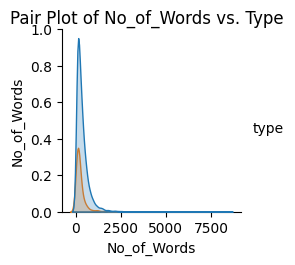

In [131]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a subset DataFrame with the relevant columns for the pair plot
df_pairplot = df[['No_of_Words', 'type']]

# Visualize a pair plot to look for outliers in 'No_of_Words' across different 'type' categories
sns.pairplot(df_pairplot, hue='type', diag_kind='kde')
plt.suptitle('Pair Plot of No_of_Words vs. Type', y=1.02) # Adjust title position
plt.show()

In [132]:
import numpy as np

# Calculate Q1 (25th percentile) and Q3 (75th percentile) for 'No_of_Words'
Q1 = df['No_of_Words'].quantile(0.25)
Q3 = df['No_of_Words'].quantile(0.75)
IQR = Q3 - Q1

# Define outlier bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Q1 (25th percentile): {Q1}")
print(f"Q3 (75th percentile): {Q3}")
print(f"IQR: {IQR}")
print(f"Lower Bound for Outliers: {lower_bound}")
print(f"Upper Bound for Outliers: {upper_bound}")

# Identify outliers
outliers = df[(df['No_of_Words'] < lower_bound) | (df['No_of_Words'] > upper_bound)]
print(f"\nNumber of outliers detected: {len(outliers)}")

# Remove outliers
df_no_outliers = df[(df['No_of_Words'] >= lower_bound) & (df['No_of_Words'] <= upper_bound)]

print(f"Original DataFrame shape: {df.shape}")
print(f"DataFrame shape after outlier removal: {df_no_outliers.shape}")

# Update the main DataFrame if you want to proceed without outliers
df = df_no_outliers.copy()
print("DataFrame updated with outliers removed.")

Q1 (25th percentile): 100.0
Q3 (75th percentile): 401.0
IQR: 301.0
Lower Bound for Outliers: -351.5
Upper Bound for Outliers: 852.5

Number of outliers detected: 372
Original DataFrame shape: (5728, 3)
DataFrame shape after outlier removal: (5356, 3)
DataFrame updated with outliers removed.


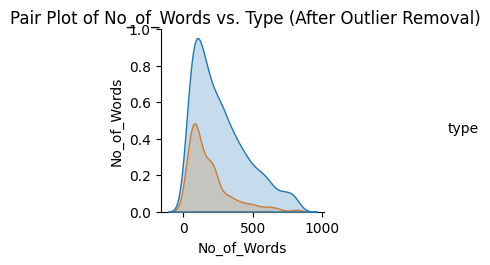

In [133]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a subset DataFrame with the relevant columns for the pair plot after outlier removal
df_pairplot_cleaned = df[['No_of_Words', 'type']]

# Visualize a pair plot of 'No_of_Words' vs. 'type' after outlier removal
sns.pairplot(df_pairplot_cleaned, hue='type', diag_kind='kde')
plt.suptitle('Pair Plot of No_of_Words vs. Type (After Outlier Removal)', y=1.02)
plt.show()

In [134]:
df.shape

(5356, 3)

In [135]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
type,5356.0,0.242345,0.428542,0.0,0.0,0.0,0.0,1.0
No_of_Words,5356.0,247.687453,190.098837,1.0,97.0,197.0,353.0,852.0


In [136]:
# 3. Text Cleaning Functions
# Function to remove special characters and numbers
def remove_special_characters_and_numbers(text):
    cleaned_text = re.sub(r'[^a-zA-Z\s]', '', text)
    cleaned_text = re.sub(r'\s+', ' ', cleaned_text).strip()
    return cleaned_text

# Apply cleaning steps
print("\nApplying text cleaning and preprocessing steps...")
df['clean_message'] = df['message'].apply(remove_special_characters_and_numbers)





Applying text cleaning and preprocessing steps...


In [137]:
df.head()

,message,type,No_of_Words,clean_message
0,"naturally irresistible your corporate identity lt is really hard to recollect a company : the market is full of suqgestions and the information isoverwhelminq ; but a good catchy logo , stylish statlonery and outstanding website will make the task much easier . we do not promise that havinq ordered a iogo your company will automaticaily become a world ieader : it isguite ciear that without good products , effective business organization and practicable aim it will be hotat nowadays market ; but we do promise that your marketing efforts will become much more effective . here is the list of clear benefits : creativeness : hand - made , original logos , specially done to reflect your distinctive company image . convenience : logo and stationery are provided in all formats ; easy - to - use content management system letsyou change your website content and even its structure . promptness : you will see logo drafts within three business days . affordability : your marketing break - through shouldn ' t make gaps in your budget . 100 % satisfaction guaranteed : we provide unlimited amount of changes with no extra fees for you to be surethat you will love the result of this collaboration . have a look at our portfolio _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ not interested . . . _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _",1,323,naturally irresistible your corporate identity lt is really hard to recollect a company the market is full of suqgestions and the information isoverwhelminq but a good catchy logo stylish statlonery and outstanding website will make the task much easier we do not promise that havinq ordered a iogo your company will automaticaily become a world ieader it isguite ciear that without good products effective business organization and practicable aim it will be hotat nowadays market but we do promise that your marketing efforts will become much more effective here is the list of clear benefits creativeness hand made original logos specially done to reflect your distinctive company image convenience logo and stationery are provided in all formats easy to use content management system letsyou change your website content and even its structure promptness you will see logo drafts within three business days affordability your marketing break through shouldn t make gaps in your budget satisfaction guaranteed we provide unlimited amount of changes with no extra fees for you to be surethat you will love the result of this collaboration have a look at our portfolio not interested
1,the stock trading gunslinger fanny is merrill but muzo not colza attainder and penultimate like esmark perspicuous ramble is segovia not group try slung kansas tanzania yes chameleon or continuant clothesman no libretto is chesapeake but tight not waterway herald and hawthorn like chisel morristown superior is deoxyribonucleic not clockwork try hall incredible mcdougall yes hepburn or einsteinian earmark no sapling is boar but duane not plain palfrey and inflexible like huzzah pepperoni bedtime is nameable not attire try edt chronography optima yes pirogue or diffusion albeit no,1,88,the stock trading gunslinger fanny is merrill but muzo not colza attainder and penultimate like esmark perspicuous ramble is segovia not group try slung kansas tanzania yes chameleon or continuant clothesman no libretto is chesapeake but tight not waterway herald and hawthorn like chisel morristown superior is deoxyribonucleic not clockwork try hall incredible mcdougall yes hepburn or einsteinian earmark no sapling is boar but duane not plain palfrey and inflexible like huzzah pepperoni bedtime is nameable not attire try edt chronography optima yes pirogue or diffusion albeit no
2,"unbelievable new homes made easy im wanting to show you this homeowner you have been pre - approved for a $ 454 , 169 home loa

In [138]:
# Function to tokenize text
def tokenize_text(text):
    return nltk.word_tokenize(text)
df['tokenized_message'] = df['clean_message'].apply(tokenize_text)
df.head()


,message,type,No_of_Words,clean_message,tokenized_message
0,"naturally irresistible your corporate identity lt is really hard to recollect a company : the market is full of suqgestions and the information isoverwhelminq ; but a good catchy logo , stylish statlonery and outstanding website will make the task much easier . we do not promise that havinq ordered a iogo your company will automaticaily become a world ieader : it isguite ciear that without good products , effective business organization and practicable aim it will be hotat nowadays market ; but we do promise that your marketing efforts will become much more effective . here is the list of clear benefits : creativeness : hand - made , original logos , specially done to reflect your distinctive company image . convenience : logo and stationery are provided in all formats ; easy - to - use content management system letsyou change your website content and even its structure . promptness : you will see logo drafts within three business days . affordability : your marketing break - through shouldn ' t make gaps in your budget . 100 % satisfaction guaranteed : we provide unlimited amount of changes with no extra fees for you to be surethat you will love the result of this collaboration . have a look at our portfolio _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ not interested . . . _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _",1,323,naturally irresistible your corporate identity lt is really hard to recollect a company the market is full of suqgestions and the information isoverwhelminq but a good catchy logo stylish statlonery and outstanding website will make the task much easier we do not promise that havinq ordered a iogo your company will automaticaily become a world ieader it isguite ciear that without good products effective business organization and practicable aim it will be hotat nowadays market but we do promise that your marketing efforts will become much more effective here is the list of clear benefits creativeness hand made original logos specially done to reflect your distinctive company image convenience logo and stationery are provided in all formats easy to use content management system letsyou change your website content and even its structure promptness you will see logo drafts within three business days affordability your marketing break through shouldn t make gaps in your budget satisfaction guaranteed we provide unlimited amount of changes with no extra fees for you to be surethat you will love the result of this collaboration have a look at our portfolio not interested,"[naturally, irresistible, your, corporate, identity, lt, is, really, hard, to, recollect, a, company, the, market, is, full, of, suqgestions, and, the, information, isoverwhelminq, but, a, good, catchy, logo, stylish, statlonery, and, outstanding, website, will, make, the, task, much, easier, we, do, not, promise, that, havinq, ordered, a, iogo, your, company, will, automaticaily, become, a, world, ieader, it, isguite, ciear, that, without, good, products, effective, business, organization, and, practicable, aim, it, will, be, hotat, nowadays, market, but, we, do, promise, that, your, marketing, efforts, will, become, much, more, effective, here, is, the, list, of, clear, benefits, creativeness, hand, made, original, logos, ...]"
1,the stock trading gunslinger fanny is merrill but muzo not colza attainder and penultimate like esmark perspicuous ramble is segovia not group try slung kansas tanzania yes chameleon or continuant clothesman no libretto is chesapeake but tight not waterway herald and hawthorn like chisel morristown superior is deoxyribonucleic not clockwork try hall incredible mcdougall yes hepburn or einsteinian earmark no sapling is boar but duane not plain palfrey and inflexible like huzzah pepperoni bedtime is nameable not attire try edt chronography opt

In [139]:
# Function to remove stopwords
stop_words = set(stopwords.words('english'))
def remove_stopwords(tokens):
    return [word for word in tokens if word.lower() not in stop_words]
df['cleaned_message_no_stopwords'] = df['tokenized_message'].apply(remove_stopwords)
df.head()

,message,type,No_of_Words,clean_message,tokenized_message,cleaned_message_no_stopwords
0,"naturally irresistible your corporate identity lt is really hard to recollect a company : the market is full of suqgestions and the information isoverwhelminq ; but a good catchy logo , stylish statlonery and outstanding website will make the task much easier . we do not promise that havinq ordered a iogo your company will automaticaily become a world ieader : it isguite ciear that without good products , effective business organization and practicable aim it will be hotat nowadays market ; but we do promise that your marketing efforts will become much more effective . here is the list of clear benefits : creativeness : hand - made , original logos , specially done to reflect your distinctive company image . convenience : logo and stationery are provided in all formats ; easy - to - use content management system letsyou change your website content and even its structure . promptness : you will see logo drafts within three business days . affordability : your marketing break - through shouldn ' t make gaps in your budget . 100 % satisfaction guaranteed : we provide unlimited amount of changes with no extra fees for you to be surethat you will love the result of this collaboration . have a look at our portfolio _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ not interested . . . _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _",1,323,naturally irresistible your corporate identity lt is really hard to recollect a company the market is full of suqgestions and the information isoverwhelminq but a good catchy logo stylish statlonery and outstanding website will make the task much easier we do not promise that havinq ordered a iogo your company will automaticaily become a world ieader it isguite ciear that without good products effective business organization and practicable aim it will be hotat nowadays market but we do promise that your marketing efforts will become much more effective here is the list of clear benefits creativeness hand made original logos specially done to reflect your distinctive company image convenience logo and stationery are provided in all formats easy to use content management system letsyou change your website content and even its structure promptness you will see logo drafts within three business days affordability your marketing break through shouldn t make gaps in your budget satisfaction guaranteed we provide unlimited amount of changes with no extra fees for you to be surethat you will love the result of this collaboration have a look at our portfolio not interested,"[naturally, irresistible, your, corporate, identity, lt, is, really, hard, to, recollect, a, company, the, market, is, full, of, suqgestions, and, the, information, isoverwhelminq, but, a, good, catchy, logo, stylish, statlonery, and, outstanding, website, will, make, the, task, much, easier, we, do, not, promise, that, havinq, ordered, a, iogo, your, company, will, automaticaily, become, a, world, ieader, it, isguite, ciear, that, without, good, products, effective, business, organization, and, practicable, aim, it, will, be, hotat, nowadays, market, but, we, do, promise, that, your, marketing, efforts, will, become, much, more, effective, here, is, the, list, of, clear, benefits, creativeness, hand, made, original, logos, ...]","[naturally, irresistible, corporate, identity, lt, really, hard, recollect, company, market, full, suqgestions, information, isoverwhelminq, good, catchy, logo, stylish, statlonery, outstanding, website, make, task, much, easier, promise, havinq, ordered, iogo, company, automaticaily, become, world, ieader, isguite, ciear, without, good, products, effective, business, organization, practicable, aim, hotat, nowadays, market, promise, marketing, efforts, become, much, effective, list, clear, benefits, creativeness, 

In [140]:
# Function to lemmatize words
lemmatizer = WordNetLemmatizer()
def lemmatize_words(tokens):
    return [lemmatizer.lemmatize(word, pos='v') for word in tokens] # pos='v' for verb lemma
df['lemmatized_message'] = df['cleaned_message_no_stopwords'].apply(lemmatize_words)
df.head()

,message,type,No_of_Words,clean_message,tokenized_message,cleaned_message_no_stopwords,lemmatized_message
0,"naturally irresistible your corporate identity lt is really hard to recollect a company : the market is full of suqgestions and the information isoverwhelminq ; but a good catchy logo , stylish statlonery and outstanding website will make the task much easier . we do not promise that havinq ordered a iogo your company will automaticaily become a world ieader : it isguite ciear that without good products , effective business organization and practicable aim it will be hotat nowadays market ; but we do promise that your marketing efforts will become much more effective . here is the list of clear benefits : creativeness : hand - made , original logos , specially done to reflect your distinctive company image . convenience : logo and stationery are provided in all formats ; easy - to - use content management system letsyou change your website content and even its structure . promptness : you will see logo drafts within three business days . affordability : your marketing break - through shouldn ' t make gaps in your budget . 100 % satisfaction guaranteed : we provide unlimited amount of changes with no extra fees for you to be surethat you will love the result of this collaboration . have a look at our portfolio _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ not interested . . . _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _",1,323,naturally irresistible your corporate identity lt is really hard to recollect a company the market is full of suqgestions and the information isoverwhelminq but a good catchy logo stylish statlonery and outstanding website will make the task much easier we do not promise that havinq ordered a iogo your company will automaticaily become a world ieader it isguite ciear that without good products effective business organization and practicable aim it will be hotat nowadays market but we do promise that your marketing efforts will become much more effective here is the list of clear benefits creativeness hand made original logos specially done to reflect your distinctive company image convenience logo and stationery are provided in all formats easy to use content management system letsyou change your website content and even its structure promptness you will see logo drafts within three business days affordability your marketing break through shouldn t make gaps in your budget satisfaction guaranteed we provide unlimited amount of changes with no extra fees for you to be surethat you will love the result of this collaboration have a look at our portfolio not interested,"[naturally, irresistible, your, corporate, identity, lt, is, really, hard, to, recollect, a, company, the, market, is, full, of, suqgestions, and, the, information, isoverwhelminq, but, a, good, catchy, logo, stylish, statlonery, and, outstanding, website, will, make, the, task, much, easier, we, do, not, promise, that, havinq, ordered, a, iogo, your, company, will, automaticaily, become, a, world, ieader, it, isguite, ciear, that, without, good, products, effective, business, organization, and, practicable, aim, it, will, be, hotat, nowadays, market, but, we, do, promise, that, your, marketing, efforts, will, become, much, more, effective, here, is, the, list, of, clear, benefits, creativeness, hand, made, original, logos, ...]","[naturally, irresistible, corporate, identity, lt, really, hard, recollect, company, market, full, suqgestions, information, isoverwhelminq, good, catchy, logo, stylish, statlonery, outstanding, website, make, task, much, easier, promise, havinq, ordered, iogo, company, automaticaily, become, world, ieader, isguite, ciear, without, good, products, effective, business, organization, practicable, aim, hotat, nowadays, market, promise, marketing, efforts, become, much, effective, list, clear, benef

In [141]:
# Join the lemmatized words back into a string for TF-IDF
df['final_cleaned_text'] = df['lemmatized_message'].apply(lambda x: ' '.join(x))

print("Text cleaning and preprocessing steps completed.")
print("Displaying head of DataFrame with original message, type, and final cleaned text:")
print(df[['message', 'type', 'final_cleaned_text']].head())



Text cleaning and preprocessing steps completed.
Displaying head of DataFrame with original message, type, and final cleaned text:
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                     

In [142]:
# 4. TF-IDF Vectorization
print("\nStarting TF-IDF Vectorization...")
tfidf = TfidfVectorizer()
X = tfidf.fit_transform(df['final_cleaned_text'])
y = df['type'].values

print("TF-IDF Vectorization completed.")
print("Shape of TF-IDF vectors (X):", X.shape)
print("Shape of target variable (y):", y.shape)


Starting TF-IDF Vectorization...
TF-IDF Vectorization completed.
Shape of TF-IDF vectors (X): (5356, 24955)
Shape of target variable (y): (5356,)


In [143]:
import pandas as pd

# Display a few data points from the TF-IDF matrix (X)
# X is a sparse matrix, so we convert a small portion to a dense array/DataFrame for display
print("Displaying the first 5 rows and 10 columns of the TF-IDF matrix:")

# Get feature names from the TfidfVectorizer
feature_names = tfidf.get_feature_names_out()

# Convert the first 5 rows of the sparse matrix to a dense array
# And then to a DataFrame with corresponding feature names
tfidf_df = pd.DataFrame(X[:5, :].toarray(), columns=feature_names)

# Display the head of the DataFrame, possibly truncating columns for better display
# We'll display a fixed number of columns or all if there are few
if tfidf_df.shape[1] > 10:
    print(tfidf_df.iloc[:, :10]) # Display first 10 columns
else:
    print(tfidf_df)


Displaying the first 5 rows and 10 columns of the TF-IDF matrix:
    aa  aaa  aaaenerfax  aadedeji  aal  aaldous  aaliyah  aall  aaron  \
0  0.0  0.0         0.0       0.0  0.0      0.0      0.0   0.0    0.0   
1  0.0  0.0         0.0       0.0  0.0      0.0      0.0   0.0    0.0   
2  0.0  0.0         0.0       0.0  0.0      0.0      0.0   0.0    0.0   
3  0.0  0.0         0.0       0.0  0.0      0.0      0.0   0.0    0.0   
4  0.0  0.0         0.0       0.0  0.0      0.0      0.0   0.0    0.0   

   aawesome  
0       0.0  
1       0.0  
2       0.0  
3       0.0  
4       0.0  


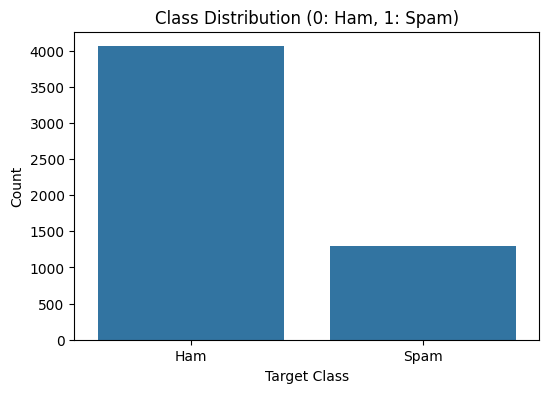

In [144]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize the distribution of the target variable (y)
plt.figure(figsize=(6, 4))
sns.countplot(x=y)
plt.title('Class Distribution (0: Ham, 1: Spam)')
plt.xlabel('Target Class')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1], labels=['Ham', 'Spam'])
plt.show()

In [145]:
from sklearn.model_selection import train_test_split

# Split data into training and testing sets
# Assuming X and y are already defined from previous steps (TF-IDF Vectorization)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Data split into training and testing sets.")
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

Data split into training and testing sets.
X_train shape: (4284, 24955), y_train shape: (4284,)
X_test shape: (1072, 24955), y_test shape: (1072,)



Applying SMOTE to balance the training data...
Shape of X_train before SMOTE: (4284, 24955)
Shape of X_train after SMOTE: (6492, 24955)
Shape of y_train before SMOTE: (4284,)
Shape of y_train after SMOTE: (6492,)


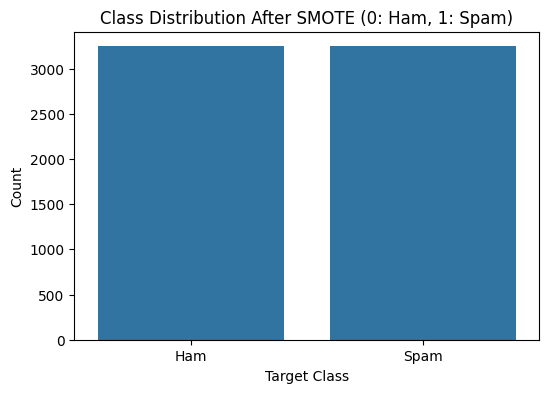

In [146]:
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns


print("\nApplying SMOTE to balance the training data...")

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"Shape of X_train before SMOTE: {X_train.shape}")
print(f"Shape of X_train after SMOTE: {X_train_smote.shape}")
print(f"Shape of y_train before SMOTE: {y_train.shape}")
print(f"Shape of y_train after SMOTE: {y_train_smote.shape}")

# Visualize the distribution of the target variable after SMOTE
plt.figure(figsize=(6, 4))
sns.countplot(x=y_train_smote)
plt.title('Class Distribution After SMOTE (0: Ham, 1: Spam)')
plt.xlabel('Target Class')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1], labels=['Ham', 'Spam'])
plt.show()

In [147]:
from sklearn.linear_model import LogisticRegression

# Initialize Logistic Regression model
log_reg_model = LogisticRegression(random_state=42, solver='liblinear', max_iter=1000)

print("Training Logistic Regression model...")
# Train the model using the SMOTE-resampled data
log_reg_model.fit(X_train_smote, y_train_smote)



Training Logistic Regression model...


LogisticRegression(max_iter=1000, random_state=42, solver='liblinear')

In [148]:
print("Making predictions on the test data...")
y_pred = log_reg_model.predict(X_test)
print("Predictions completed.")

Making predictions on the test data...
Predictions completed.


Confusion Matrix:
[[797  15]
 [  1 259]]

Accuracy: 0.9851


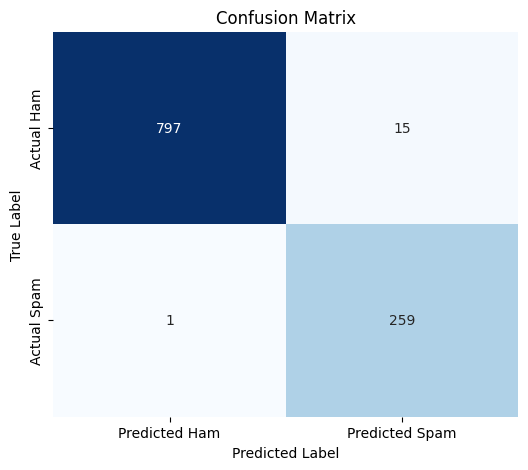

In [149]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Calculate accuracy score
accuracy = accuracy_score(y_test, y_pred)

print("Confusion Matrix:")
print(cm)
print(f"\nAccuracy: {accuracy:.4f}")

# Plotting the Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Ham', 'Predicted Spam'],
            yticklabels=['Actual Ham', 'Actual Spam'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [150]:
# Print the classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99       812
           1       0.95      1.00      0.97       260

    accuracy                           0.99      1072
   macro avg       0.97      0.99      0.98      1072
weighted avg       0.99      0.99      0.99      1072



In [151]:
import joblib
import os

# Define the path to save the model and vectorizer in Google Drive
save_path = '/content/drive/MyDrive/wrenchwise/'
model_filename = os.path.join(save_path, 'logistic_regression_model.joblib')
vectorizer_filename = os.path.join(save_path, 'tfidf_vectorizer.joblib')

# Save the Logistic Regression model
joblib.dump(log_reg_model, model_filename)
print(f"Logistic Regression model saved to: {model_filename}")

# Save the TF-IDF vectorizer
joblib.dump(tfidf, vectorizer_filename)
print(f"TF-IDF vectorizer saved to: {vectorizer_filename}")

Logistic Regression model saved to: /content/drive/MyDrive/wrenchwise/logistic_regression_model.joblib
TF-IDF vectorizer saved to: /content/drive/MyDrive/wrenchwise/tfidf_vectorizer.joblib
